# Read Data

In [1]:
# pip install -U transformers datasets accelerate scikit-learn pandas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

In [2]:
from google.colab import drive
import os
import pickle
drive.mount('/content/drive', force_remount = True)
os.chdir('/content/drive/MyDrive')
df_train = pd.read_csv("train_sentiment.csv")# read data
df_test = pd.read_csv("test_sentiment.csv")

Mounted at /content/drive


In [3]:
df = pd.read_csv("data_extension_sentiment.csv")

In [4]:
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

# Apply mapping
df_train["sentiment"] = df_train["label"].map(label_map)
df_test["sentiment"] = df_test["label"].map(label_map)


In [5]:
df = df.rename(columns = {"sentence": "text"})

In [6]:
# 2) Encode labels
le = LabelEncoder()
df_train["label"] = le.fit_transform(df_train["sentiment"])
df_test["label"] = le.transform(df_test["sentiment"])
df["label"] = le.transform(df["sentiment"])

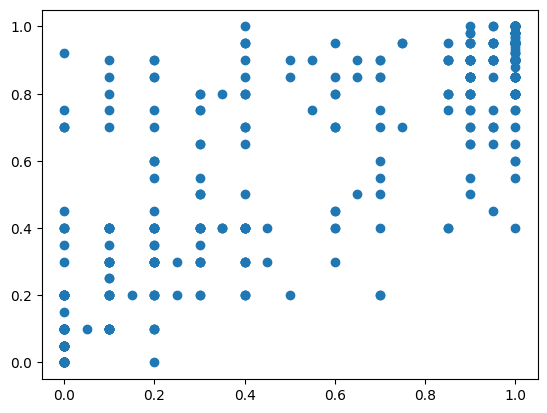

In [7]:
import matplotlib.pyplot as plt
plt.scatter(df["pro-score"].iloc[:500], df["flash-score"].iloc[:500])

In [8]:
df_train.head(6)

,text,label,sentiment
0,i only played the london mission from the demo...,5,surprise
1,i am feeling fearful confused a deep and profo...,1,fear
2,i go overboard with my sense of duty and respo...,4,sadness
3,i feel most passionate about and currently thi...,3,love
4,i feel almost embarrassed to be writing its be...,4,sadness
5,i was left feeling a bit dazed and confused as...,5,surprise


# LDA

In [9]:
import re
from sklearn.feature_extraction.text import CountVectorizer

texts = df_train["text"].astype(str).tolist()
def simple_clean(t):
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s'-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t
texts = [simple_clean(t) for t in texts]


vect = CountVectorizer(stop_words="english", min_df=5, max_df=0.9)
X = vect.fit_transform(texts)
vocab = vect.get_feature_names_out()

from sklearn.decomposition import LatentDirichletAllocation


lda = LatentDirichletAllocation(n_components=6, random_state=42, max_iter=40, n_jobs=-1)
all_embedding = lda.fit_transform(X)


# LAKCP

In [10]:
!pip install ternary
from LatentKernCP.lakcp import LAKCP


  Preparing metadata (setup.py) ... done
  Created wheel for ternary: filename=ternary-0.1-py3-none-any.whl size=1751 sha256=d39b6c2cdbfbbd6f5d16c65423b12a4e7ef1f4b3a7b90181841879acb32b39e1
  Stored in directory: /root/.cache/pip/wheels/d7/6e/54/60848f233a06e5db63831ed34cf4210628ba15030f8b6b4fa3
Successfully built ternary


In [11]:
def compute_lambda(df, exception):
  lambdas = []
  for i in range(100):
    sub_df = df.iloc[(5 * i):(5 * (i + 1)),: ]

    sorted_df = sub_df.sort_values("flash-score")

    lambda_val = None

    for i, candidate in enumerate(sorted_df["flash-score"]):
        # Subset where flash-score >= candidate
        subset = sub_df.loc[sub_df["flash-score"] >= candidate]

        # Count exceptions (pro-score != 1)
        exceptions = (subset["pro-score"] < .5).sum()

        if exceptions <= exception:   # allow at most three exception
            lambda_val = candidate
            break
    if lambda_val is None:
      lambda_val = 1
    lambdas.append(lambda_val)

  return np.array(lambdas)


In [12]:
names = ["lambda1"]
exceptions = [1]
lambdas_ls = []
cutoffs = []
for i, name in enumerate(names):
  alpha = .1
  lambdas = compute_lambda(df, exceptions[i])
  Zcal = all_embedding[:100, :]
  Ztest =  all_embedding[100:, :]
  res_cal = lambdas


  print("Starting LAKCP...")
  lakcp = LAKCP(
      alpha=alpha,
      max_steps=200,
      eps=1e-03,
      tol=1e-06,
      thres=10.0,
      ridge=1e-08,
      start_side='left',
      gamma=None,
      gamma_grid=np.logspace(-1, 1, 30),
      randomize=False,
      verbose=False
  )

  # If you later add KMeans on Ztrain_pca (fit ONCE & save centroids), create one-hot Φ_cal/Φ_test.
  Phi_cal  = np.ones((Zcal.shape[0], 1))
  Phi_test = np.ones((Ztest.shape[0], 1))

  cutoffs_lakcp = lakcp.fit(Zcal, Phi_cal, res_cal.ravel(),
                            Ztest, Phi_test)

  # === LAKCP (CV) ====
  print("Starting LAKCP with CV...")
  lakcp_cv = LAKCP(
      alpha=alpha,
      max_steps=200,
      eps=1e-03,
      tol=1e-06,
      thres=10.0,
      ridge=1e-08,
      start_side='left',
      gamma=None,
      gamma_grid=np.logspace(-1, 1, 30),
      use_cv=True,
      randomize=True,
      verbose=False
  )
  cutoffs_lakcp_cv = lakcp_cv.fit(Zcal, Phi_cal, res_cal.ravel(),
                            Ztest, Phi_test)
  cutoffs.append(cutoffs_lakcp_cv[0])
  lambdas_ls.append(lambdas)


Starting LAKCP...
Starting LAKCP with CV...


In [13]:
np.mean(lambdas)

np.float64(0.6527000000000001)

In [14]:
df["lambda1"] = 0

for i in range(100):
  df.iloc[ (i * 5): ((i + 1) * 5) , 5] = lambdas_ls[0][i]

for i in range(100, 1000):
  df.iloc[ (i * 5): ((i + 1) * 5) , 5] = cutoffs[0][i- 100]


/tmp/ipython-input-1112910873.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.92' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[ (i * 5): ((i + 1) * 5) , 5] = lambdas_ls[0][i]


# Performance

In [ ]:
# Small LM fine-tune with LoRA (PEFT) — drop-in for your DatasetDict
# pip install transformers peft accelerate datasets bitsandbytes (if GPU + 4bit)

import numpy as np
from datasets import DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

def train_and_eval_small_lm_lora(
    dataset: DatasetDict,
    model_name: str = "distilbert-base-uncased",
    run_name: str = "small_lm_lora",
    max_length: int = 192,
    lora_r: int = 8,
    lora_alpha: int = 16,
    lora_dropout: float = 0.1,
    lr: float = 2e-4,
    batch_size: int = 32,
    num_epochs: int = 20,
):
    # infer num labels
    labels = list(set(dataset["train"]["label"]))
    label2id = {y:i for i,y in enumerate(sorted(labels))}
    id2label = {i:y for y,i in label2id.items()}

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    def preprocess(batch):
        y = [label2id[v] for v in batch["label"]]
        x = tokenizer(batch["text"], truncation=True, max_length=max_length)
        x["labels"] = y
        return x

    ds_proc = DatasetDict({
        split: ds.map(preprocess, batched=True, remove_columns=ds.column_names)
        for split, ds in dataset.items()
    })

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    # Set up LoRA on attention projections (common, lightweight)
    peft_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        target_modules=["q_lin","k_lin","v_lin","out_lin","query","key","value","dense"]  # robust across archs
    )
    model = get_peft_model(base_model, peft_cfg)

    # Training args with early stopping on your validation split
    args = TrainingArguments(
        output_dir=f"./runs/{run_name}",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available(),  # use fp16 if possible
        seed=42,
        disable_tqdm=True, # Add this line
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_proc["train"],
        eval_dataset=ds_proc["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # Evaluate
    test_metrics = trainer.evaluate(ds_proc["test"])

    outdir = f"./runs/{run_name}"
    if os.path.exists(outdir):
        shutil.rmtree(outdir)  # removes the whole folder with checkpoints
        print(f"Deleted {outdir}")

    return {
        "test": {k: float(v) for k, v in test_metrics.items() if k.startswith("eval_")},
        "run_name": run_name,
        "model_name": model_name,
        "trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

In [ ]:
import numpy as np
import pandas as pd
import shutil


final_res = []
for iii in range(20):
  np.random.seed( iii)

  first_100 = np.arange(100)

  random_400 = np.random.choice(
      np.arange(100, df_train.shape[0]),
      size=200,
      replace=False
  )

  selected_index = np.concatenate([first_100, random_400])
  print(sum(selected_index))
  df1 = df_train.iloc[selected_index, :][["text", "label"]]

  selected_index2 = np.concatenate([np.arange(5 * j, 5 * (j + 1)) for j in selected_index])
  print(sum(selected_index2))

  df_sub = df.iloc[selected_index2, :]


  df2 = df_sub[["text", "label"]]


  df3 = df_sub.loc[df_sub["flash-score"] >= 0.5, ["text", "label"]]

  df4 = df_sub.loc[ (df_sub["pro-score"] >= 0.5) | ((df_sub["pro-score"] == -1) & (df_sub["flash-score"] >= 0.5)), ["text", "label"]
  ]

  df5 = df_sub.loc[
      (df_sub["pro-score"] >= .5) |
      ((df_sub["pro-score"] == -1) & (df_sub["flash-score"] >= df_sub["lambda1"])),
      ["text", "label"]
  ]


  dfs = [df1, df2, df3, df4, df5]
  print(df1.shape)
  print(df2.shape)
  print(df3.shape)
  print(df4.shape)
  print(df5.shape)
  datasets = []

  for i, dff in enumerate(dfs):

    if i == 0:
      cur_df = dff
    else:
      cur_df = pd.concat((df1, dff), axis = 0, ignore_index = True)
    datasets.append(DatasetDict({
        "train": Dataset.from_pandas(cur_df[["text", "label"]]),
        "validation": Dataset.from_pandas(df_train.iloc[400:500, :][["text", "label"]]),
        "test": Dataset.from_pandas(df_test[["text", "label"]]),
    }))


  all_results = []
  for i, ds in enumerate(datasets):
      res = train_and_eval_small_lm_lora(ds, run_name=f"tfidf_logreg_run_{i}")
      all_results.append(res["test"])
      print(i)
  final_res.append(all_results)

118481
2965025
(300, 2)
(1500, 2)
(866, 2)
(834, 2)
(333, 2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Map:   0%|          | 0/643 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1496541435.py:90: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'eval_loss': 1.7809667587280273, 'eval_accuracy': 0.29, 'eval_precision': 0.10696278511404561, 'eval_recall': 0.29, 'eval_f1': 0.15559947299077734, 'eval_runtime': 0.0646, 'eval_samples_per_second': 1548.651, 'eval_steps_per_second': 61.946, 'epoch': 1.0}
{'eval_loss': 1.6298290491104126, 'eval_accuracy': 0.29, 'eval_precision': 0.2617515364354697, 'eval_recall': 0.29, 'eval_f1': 0.23452622657500705, 'eval_runtime': 0.0647, 'eval_samples_per_second': 1545.632, 'eval_steps_per_second': 61.825, 'epoch': 2.0}
{'loss': 1.5755, 'grad_norm': 2.8295693397521973, 'learning_rate': 0.00017666666666666666, 'epoch': 2.380952380952381}
{'eval_loss': 1.4047313928604126, 'eval_accuracy': 0.42, 'eval_precision': 0.45353127136021876, 'eval_recall': 0.42, 'eval_f1': 0.4044989875819492, 'eval_runtime': 0.0646, 'eval_samples_per_second': 1548.125, 'eval_steps_per_second': 61.925, 'epoch': 3.0}
{'eval_loss': 1.22686767578125, 'eval_accuracy': 0.53, 'eval_precision': 0.6168888152077807, 'eval_recall': 0.53

In [ ]:
with open("final_res_20_sentiment.pkl", "wb") as f:
    pickle.dump(final_res, f)


In [ ]:
with open("final_res_20_sentiment.pkl", "rb") as f:
    final_res = pickle.load(f)


In [ ]:
labels = ["original", "unfilterd", "flash", "1/5pro+4/5flash", "LAKCP"]
res1 = np.array([ [ j["eval_precision"] for j in i ] for i in final_res])
res2 = np.array([ [ j["eval_accuracy"] for j in i ] for i in final_res])
res3 = np.array([ [ j["eval_recall"] for j in i ] for i in final_res])
res4 = np.array([ [ j["eval_f1"] for j in i ] for i in final_res])

In [ ]:
final_res[0]

[{'eval_loss': 0.975533127784729,
  'eval_accuracy': 0.61,
  'eval_precision': 0.6114712823725982,
  'eval_recall': 0.61,
  'eval_f1': 0.6075214843014463,
  'eval_runtime': 0.1202,
  'eval_samples_per_second': 1663.317,
  'eval_steps_per_second': 58.216},
 {'eval_loss': 1.1104602813720703,
  'eval_accuracy': 0.61,
  'eval_precision': 0.6174441355810617,
  'eval_recall': 0.61,
  'eval_f1': 0.60472130785156,
  'eval_runtime': 0.113,
  'eval_samples_per_second': 1770.656,
  'eval_steps_per_second': 61.973},
 {'eval_loss': 1.0586918592453003,
  'eval_accuracy': 0.63,
  'eval_precision': 0.6376654595041692,
  'eval_recall': 0.63,
  'eval_f1': 0.6304369557218128,
  'eval_runtime': 0.1154,
  'eval_samples_per_second': 1733.033,
  'eval_steps_per_second': 60.656},
 {'eval_loss': 1.0518122911453247,
  'eval_accuracy': 0.645,
  'eval_precision': 0.6561738866016108,
  'eval_recall': 0.645,
  'eval_f1': 0.64667876334786,
  'eval_runtime': 0.1146,
  'eval_samples_per_second': 1744.944,
  'eval_step

In [ ]:
print(1)

1


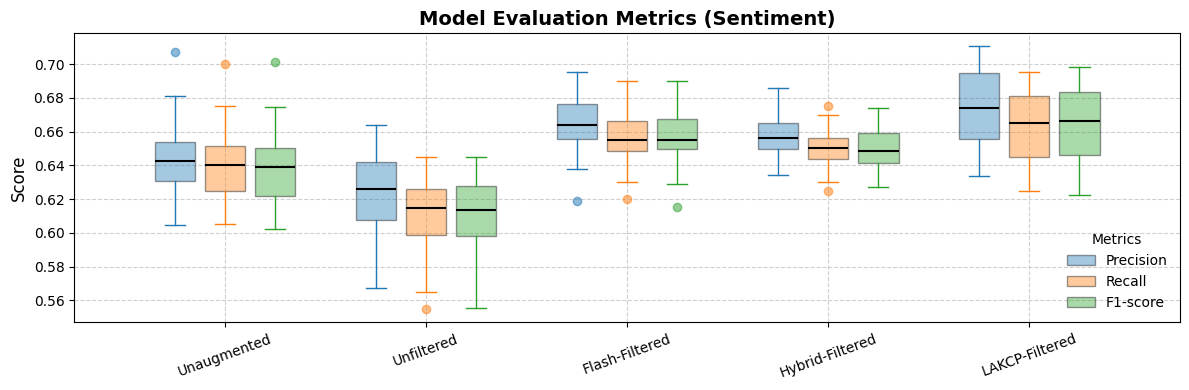

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Example labels
labels = ["Unaugmented", "Unfiltered", "Flash-Filtered", "Hybrid-Filtered", "LAKCP-Filtered"]

# Results arrays (shape: n_runs × n_labels)
metrics = {
    "Precision": res1,
    "Recall": res3,
    "F1-score": res4
}

colors = plt.cm.tab10.colors
plt.figure(figsize=(12, 4))

# X positions for each method
x = np.arange(len(labels))
width = 0.25  # box width

for i, (metric_name, res) in enumerate(metrics.items()):
    # Compute offset for dodging
    positions = x + (i - 1) * width

    # Build boxplot values column-wise
    data = [res[:, j] for j in range(res.shape[1])]

    plt.boxplot(
        data,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], alpha=0.4),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color=colors[i]),
        capprops=dict(color=colors[i]),
        flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], alpha=0.5)
    )

# Style
plt.xticks(x, labels, rotation=20)
plt.ylabel("Score", fontsize=12)
plt.title("Model Evaluation Metrics (Sentiment)", fontsize=14, fontweight="bold")
plt.grid(alpha=0.6, linestyle="--")

# Legend in bottom right
legend_elements = [Patch(facecolor=colors[i], edgecolor="black", alpha=0.4, label=metric_name)
                   for i, metric_name in enumerate(metrics.keys())]
plt.legend(handles=legend_elements, title="Metrics", frameon=False, loc="lower right")

plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

# Expected columns:
# df_train: ['symptom']
# df: ['symptom', 'flash-score', 'pro-score', 'lambda1']

rows = []
for i in range(df_train.shape[0]):
    base = df_train.at[i, 'text']

    # the 5 generated rows that correspond to this i
    sub = df.iloc[5*i:5*i+5]

    # build strings
    all_sym = '. '.join(sub['text'].astype(str))
    s_all = f"{base}. {all_sym}"

    s_flash = f"{base}. " + '. '.join(sub.loc[sub['flash-score'] >= 0.5, 'text'].astype(str))

    cond_pro_basic = (sub['pro-score'] >= 0.5) | ((sub['pro-score'] == -1) & (sub['flash-score'] >= 0.5))
    s_pro_basic = f"{base}. " + '. '.join(sub.loc[cond_pro_basic, 'text'].astype(str))

    cond_pro_lambda = (sub['pro-score'] >= 0.5) | ((sub['pro-score'] == -1) & (sub['flash-score'] >= sub['lambda1']))
    s_pro_lambda = f"{base}. " + '. '.join(sub.loc[cond_pro_lambda, 'text'].astype(str))

    rows.append({
        'Unaugmented': base,
        'Unfiltered': s_all,
        'Flash-filtered': s_flash,
        'Hybrid-filtered': s_pro_basic,
        'LACKP-filtered': s_pro_lambda
    })


dfs = pd.DataFrame(rows)


In [16]:
import pandas as pd
import numpy as np
from collections import Counter
from math import log2
import nltk
nltk.download("punkt")
nltk.download("punkt_tab") # Add this line to download the missing resource
from nltk.tokenize import word_tokenize


def shannon_entropy(texts):
    tokens = [w.lower() for t in texts for w in word_tokenize(t)]
    freqs = Counter(tokens)
    total = sum(freqs.values())
    probs = [count / total for count in freqs.values()]
    return -sum(p * log2(p) for p in probs)

for c in dfs.columns:
  print(c, shannon_entropy(dfs[c]))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Unaugmented 8.6894942661169
Unfiltered 9.344079804956612
Flash-filtered 9.229800026561897
Hybrid-filtered 9.226922361303272
LACKP-filtered 8.962213412411195
